# SigFlow-Sim v2 — Configurable Depth and Training Visualization

Enhancements:

- Adjustable signature depth from a single configuration cell
- Real-time progress bar using tqdm
- Live loss tracking
- Final training curve visualization
- Clean output summary after training


In [1]:
# Install once if needed
#!pip install numpy pandas torch matplotlib iisignature nflows yfinance tqdm scikit-learn

## Configuration — Change Model Parameters Here

In [2]:
# =========================
# GLOBAL CONFIGURATION
# =========================

WINDOW = 20
DEPTH = 7
USE_LOGSIG = True

EPOCHS = 400              # ↓ reduce slightly for stability
BATCH_SIZE = 128
LEARNING_RATE = 1e-4      # ↑ slightly more stable than 5e-5

TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN"]

# FORECAST
HORIZON = 10
N_PATHS = 50
MODE = "rolling"

# WASSERSTEIN SCHEDULE
WASS_START = 0.0
WASS_END = 0.05           # ↓ smaller = less distortion

# STABILITY (NEW)
GRAD_CLIP = 1.0
SAMPLE_SIZE = 32          # was implicitly large → unstable training

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm import tqdm

import iisignature

from sklearn.metrics.pairwise import rbf_kernel

from nflows.flows import Flow
from nflows.distributions.normal import StandardNormal
from nflows.transforms.base import CompositeTransform
from nflows.transforms.autoregressive import MaskedAffineAutoregressiveTransform

## Load Market Data

In [4]:
import numpy as np
import yfinance as yf

all_returns = []

for ticker in TICKERS:

    data = yf.download(ticker, period="10y", interval="1d")

    prices = data["Close"]

    # log returns (correct baseline)
    log_returns = np.log(prices).diff().dropna()

    # standardise properly (IMPORTANT FIX)
    mu = log_returns.mean()
    sigma = log_returns.std()

    log_returns = (log_returns - mu) / sigma

    all_returns.append(log_returns.values)

returns_array = np.concatenate(all_returns)

print("Total samples:", len(returns_array))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Total samples: 10048


## Signature / Log-Signature Computation

In [5]:
def compute_signature(window, prep):

    t = np.linspace(0, 1, len(window))
    path = np.column_stack([t, window])

    if USE_LOGSIG:
        return iisignature.logsig(path, prep)
    else:
        return iisignature.sig(path, prep)


prep = iisignature.prepare(2, DEPTH)

signatures = []
targets = []

STRIDE = 1  # NEW (more samples)

for i in range(WINDOW, len(returns_array) - 1, STRIDE):

    window = returns_array[i - WINDOW:i]

    signatures.append(compute_signature(window, prep))
    targets.append(returns_array[i])

X = torch.tensor(np.array(signatures), dtype=torch.float32)
Y = torch.tensor(np.array(targets), dtype=torch.float32).reshape(-1, 1)

print("X shape:", X.shape)

X shape: torch.Size([10027, 41])




# TRAIN / VALIDATION / TEST SPLIT



In [6]:

n = len(X)

train_end = int(0.7 * n)
val_end = int(0.85 * n)

X_train = X[:train_end]
Y_train = Y[:train_end]

X_val = X[train_end:val_end]
Y_val = Y[train_end:val_end]

X_test = X[val_end:]
Y_test = Y[val_end:]

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 7018
Validation size: 1504
Test size: 1505


## Build Neural Spline Flow

In [7]:
def build_flow(context_dim):

    transforms = []

    for _ in range(4):

        transforms.append(
            MaskedAffineAutoregressiveTransform(
                features=1,
                hidden_features=64,
                context_features=context_dim
            )
        )

    transform = CompositeTransform(transforms)

    base_dist = StandardNormal(shape=[1])

    return Flow(transform, base_dist)


flow = build_flow(X.shape[1])

optimizer = optim.Adam(flow.parameters(), lr=LEARNING_RATE)

In [8]:
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm import tqdm

import iisignature

from sklearn.metrics.pairwise import rbf_kernel

from nflows.flows import Flow
from nflows.distributions.normal import StandardNormal
from nflows.transforms.base import CompositeTransform
from nflows.transforms.autoregressive import MaskedAffineAutoregressiveTransform

## Wasserstein Loss

In [9]:
def fast_wasserstein(real, fake, k=8):

    q = torch.linspace(0.1, 0.9, k, device=real.device)

    real_q = torch.quantile(real.squeeze(), q)
    fake_q = torch.quantile(fake.squeeze(), q)

    return torch.mean((real_q - fake_q) ** 2)

## More Penalties

In [10]:
def variance_penalty(fake):
    return (torch.std(fake) - 1.0) ** 2


def mean_penalty(fake):
    return torch.mean(fake) ** 2

## Custom Loss

In [11]:
def custom_loss(flow, x_context, y_real, step=0, total_steps=1):

    log_prob = flow.log_prob(y_real, context=x_context)
    loss_mle = -log_prob.mean()

    with torch.no_grad():
        y_fake = flow.sample(SAMPLE_SIZE, context=x_context)

    loss_wass = fast_wasserstein(y_real, y_fake)

    loss_var = (torch.std(y_fake) - torch.std(y_real).detach())**2
    loss_mean = torch.mean(y_fake)**2

    alpha = WASS_START + (WASS_END - WASS_START) * (step / total_steps)

    return loss_mle + alpha * loss_wass + 0.02 * loss_var + 0.01 * loss_mean

## Testing Block

Validates:

    data integrity

    numerical stability

    model forward pass

    sampling correctness

In [12]:
print("\nRUNNING TEST SUITE\n")

# Force safety check for accidental 3D tensors
if Y.ndim == 3 and Y.shape[-1] == 1:
    Y = Y.squeeze(-1)

assert X.ndim == 2, f"X is {X.shape}, expected 2D"
assert Y.ndim == 2, f"Y is {Y.shape}, expected 2D [N,1]"
assert X.shape[0] == Y.shape[0], "X and Y size mismatch"

assert torch.isfinite(X).all()
assert torch.isfinite(Y).all()

batch_x = X[:16].float().view(-1, X.shape[1])
batch_y = Y[:16].float().view(-1, 1)

loss = custom_loss(flow, batch_x, batch_y)
assert torch.isfinite(loss)

context = X[:1].float()
samples = flow.sample(10, context=context)

# enforce consistent shape
samples = samples.view(-1, 1)

assert samples.shape == (10, 1), f"Bad shape: {samples.shape}"

print("All tests passed")


RUNNING TEST SUITE

All tests passed


## VALIDATION LOSS

In [13]:


def evaluate(flow, X_val, Y_val):

    flow.eval()

    with torch.no_grad():

        log_prob = flow.log_prob(
            Y_val,
            context=X_val
        )

        loss = -log_prob.mean()

    flow.train()

    return loss.item()

## Training with Progress Tracking

In [14]:
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from IPython.display import display, clear_output

device = "cuda" if torch.cuda.is_available() else "cpu"

X_train = X_train.float().to(device)
Y_train = Y_train.float().to(device)
X_val = X_val.float().to(device)
Y_val = Y_val.float().to(device)

flow = flow.to(device)

optimizer = optim.Adam(flow.parameters(), lr=LEARNING_RATE)

train_dataset = TensorDataset(X_train, Y_train)

loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

loss_history = []
val_loss_history = []
global_step = 0
total_steps = EPOCHS * len(loader)


def evaluate(flow, X_val, Y_val):

    flow.eval()

    with torch.no_grad():

        log_prob = flow.log_prob(
            Y_val,
            context=X_val
        )

        loss = -log_prob.mean()

    flow.train()

    return loss.item()


for epoch in range(EPOCHS):

    epoch_loss = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)

    for batch_x, batch_y in pbar:

        optimizer.zero_grad()

        loss = custom_loss(
            flow,
            batch_x,
            batch_y,
            global_step,
            total_steps
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(flow.parameters(), GRAD_CLIP)

        optimizer.step()

        epoch_loss += loss.item() * len(batch_x)
        global_step += 1

        pbar.set_postfix(batch_loss=loss.item())

    epoch_loss /= len(train_dataset)
    val_loss = evaluate(flow, X_val, Y_val)

    loss_history.append(epoch_loss)
    val_loss_history.append(val_loss)

    clear_output(wait=True)
    display(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train: {epoch_loss:.5f} | "
        f"Val: {val_loss:.5f}"
    )

'Epoch 400/400 | Train: 1.24053 | Val: 66.80379'

## SIMPLE BACKTEST

In [15]:
def simple_backtest(flow, X_test, Y_test):

    capital = 1.0

    equity_curve = [capital]

    flow.eval()

    for i in range(len(X_test)):

        context = X_test[i]

        with torch.no_grad():

            samples = flow.sample(
                100,
                context=context.unsqueeze(0)
            )

        predicted_mean = samples.mean().item()

        real_return = Y_test[i].item()

        with torch.no_grad():

            samples = flow.sample(
                200,
                context=context.unsqueeze(0)
                ).cpu().numpy().flatten()

            predicted_mean = np.mean(samples)
            predicted_std = np.std(samples)

        # smoother decision rule
        signal = predicted_mean / (predicted_std + 1e-6)

        if signal > 0.2:
            capital *= np.exp(real_return)
        else:
            capital *= np.exp(-real_return)

            equity_curve.append(capital)

    return np.array(equity_curve)



## CORE RISK METRICS

In [16]:
def compute_return_series(equity):

    returns = np.diff(np.log(equity))

    return returns


def expected_return(returns):

    return np.mean(returns)


def volatility(returns):

    return np.std(returns)


def sharpe_ratio(returns):

    mean = np.mean(returns)

    std = np.std(returns)

    if std == 0:

        return 0

    return mean / std


def max_drawdown(equity):

    peak = equity[0]

    max_dd = 0

    for value in equity:

        if value > peak:

            peak = value

        drawdown = (peak - value) / peak

        if drawdown > max_dd:

            max_dd = drawdown

    return max_dd




## VALUE AT RISK

In [17]:

def value_at_risk(returns, alpha=0.05):

    var = np.percentile(
        returns,
        100 * alpha
    )

    return var



## EXPECTED SHORTFALL

In [18]:


def expected_shortfall(returns, alpha=0.05):

    var = np.percentile(
        returns,
        100 * alpha
    )

    losses = returns[
        returns <= var
    ]

    return losses.mean()



## BASELINE MODEL

In [19]:
def baseline_model(Y_train):

    mean = Y_train.mean().item()

    std = Y_train.std().item()

    return mean, std


def evaluate_baseline(mean, Y_test):

    errors = Y_test.cpu().numpy() - mean

    mse = np.mean(errors ** 2)

    print("Baseline MSE:", mse)



## Model Check Block

In [20]:
def model_sanity_check(flow, X_test, Y_test):

    idx = np.random.randint(0, len(X_test))
    context = X_test[idx].unsqueeze(0)

    with torch.no_grad():
        samples = flow.sample(1000, context=context).cpu().numpy().flatten()

    real = Y_test.cpu().numpy().flatten()

    print("\nMODEL SANITY CHECK")

    print("Real mean:", real.mean())
    print("Gen mean:", samples.mean())

    print("Real std:", real.std())
    print("Gen std:", samples.std())

    print("Skew (gen):", np.mean((samples - samples.mean())**3))

model_sanity_check(flow, X_test, Y_test)


MODEL SANITY CHECK
Real mean: -0.014561396
Gen mean: 0.08734758
Real std: 1.0783563
Gen std: 0.7646941
Skew (gen): 0.028773544


## PIT CALIBRATION

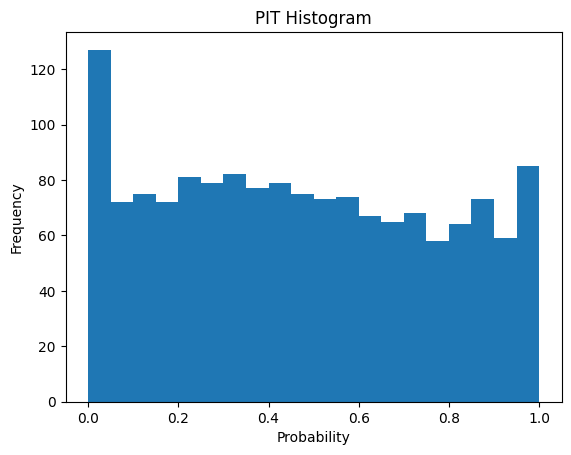

In [21]:
def pit_histogram(flow, X_test, Y_test):

    pits = []

    flow.eval()

    for i in range(len(X_test)):

        context = X_test[i]

        with torch.no_grad():

            samples = flow.sample(
                500,
                context=context.unsqueeze(0)
            ).view(-1)

        real = Y_test[i]

        prob = (samples < real).float().mean()

        pits.append(prob.item())

    plt.figure()

    plt.hist(pits, bins=20)

    plt.title("PIT Histogram")

    plt.xlabel("Probability")

    plt.ylabel("Frequency")

    plt.show()

pit_histogram(
    flow,
    X_test,
    Y_test
)

## Training Curve Visualization

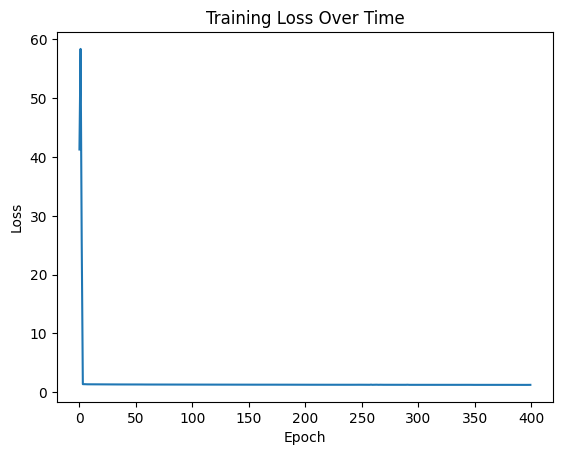

In [22]:
plt.figure()
plt.plot(loss_history)
plt.title("Training Loss Over Time")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Monte Carlo Evaluation
Evaluates model by:

    sampling multiple predictions

    comparing distribution to actual outcome

    visualising uncertainty

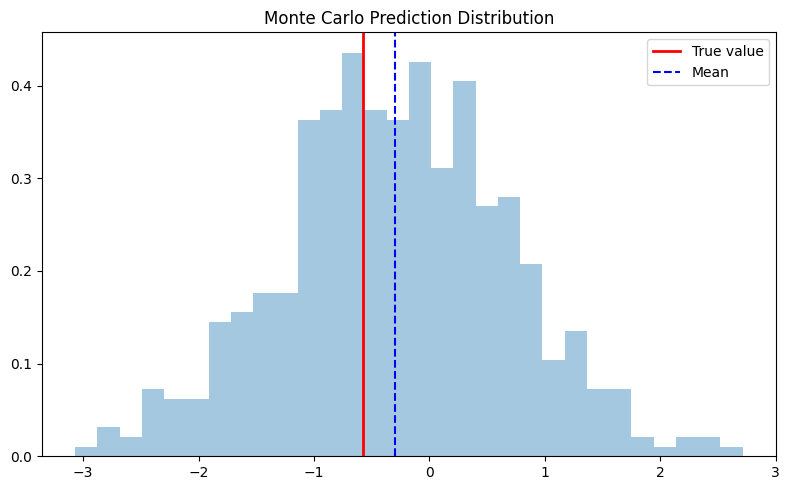


MONTE CARLO EVALUATION
Real value: -0.5756093263626099
Mean: -0.2932423
Std: 0.98195344


In [23]:

def monte_carlo_evaluation(flow, context, real_value, n_samples=500):

    import matplotlib.pyplot as plt
    import numpy as np

    # -------------------------
    # Fix context shape
    # -------------------------
    if context.ndim == 1:
        context = context.unsqueeze(0)

    context = context.float()

    # -------------------------
    # Sample
    # -------------------------
    samples = flow.sample(n_samples, context=context)
    samples = samples.view(-1).detach().cpu().numpy()

    real_value = real_value.view(-1).item()

    mean = samples.mean()
    std = samples.std()

    # -------------------------
    # Plot
    # -------------------------
    plt.figure(figsize=(8, 5))

    plt.hist(samples, bins=30, density=True, alpha=0.4)
    plt.axvline(real_value, color='red', linewidth=2, label="True value")
    plt.axvline(mean, color='blue', linestyle='--', label="Mean")

    plt.title("Monte Carlo Prediction Distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -------------------------
    # Print stats
    # -------------------------
    print("\nMONTE CARLO EVALUATION")
    print("Real value:", real_value)
    print("Mean:", mean)
    print("Std:", std)

    return samples


# -------------------------
# CALL IT HERE (THIS IS THE KEY FIX)
# -------------------------

test_idx = -1

context = X[test_idx].float()
real = Y[test_idx]

samples = monte_carlo_evaluation(flow, context, real, n_samples=500)

## Posterior Predictive Output

Prediction mean: -0.29439319940970743
Prediction std: 0.99504031625445


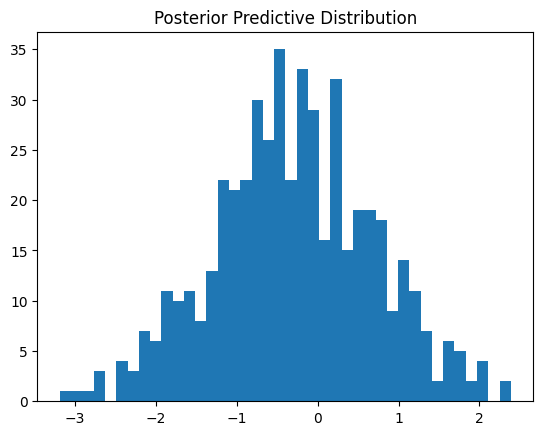

In [24]:
def posterior_predictive(flow, context, n_samples=500):

    samples = []

    for _ in range(n_samples):

        s = flow.sample(1, context=context.unsqueeze(0))

        samples.append(s.item())

    samples = np.array(samples)

    mean = np.mean(samples)
    std = np.std(samples)

    return samples, mean, std

latest_context = X[-1]

samples, mean, std = posterior_predictive(flow, latest_context)

print("Prediction mean:", mean)
print("Prediction std:", std)

plt.figure()
plt.hist(samples, bins=40)
plt.title("Posterior Predictive Distribution")
plt.show()

## Path Generation

In [25]:
import numpy as np
import torch

def generate_paths(flow, context, horizon=HORIZON, n_paths=N_PATHS, mode=MODE):

    paths = []

    for _ in range(n_paths):

        current = context.clone()
        path = []

        for t in range(horizon):

            sample = flow.sample(1, context=current.unsqueeze(0))
            r = sample.item()

            path.append(r)

            if mode == "rolling":
                current = torch.roll(current, shifts=-1)
                current[-1] = r

        paths.append(path)

    return np.array(paths)

## Price Conversion

In [26]:
def returns_to_price(start_price, returns):

    prices = [float(start_price)]

    for r in np.asarray(returns).flatten():

        prices.append(prices[-1] * np.exp(float(r)))

    return np.array(prices, dtype=np.float32)

## Outlier Function

In [27]:
import numpy as np

def detect_outliers(data):

    data = np.array(data)

    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (data < lower) | (data > upper)

    outliers = data[mask]

    return mask, outliers, lower, upper

## Visualisation System

In [28]:
import matplotlib.pyplot as plt
import numpy as np

def forecast_visual(flow, X, returns_array, idx=-200):

    context = X[idx]

    # -------------------------
    # SAFE ACTUAL PATH
    # -------------------------
    actual_returns = returns_array[idx : idx + HORIZON]
    actual_returns = np.array(actual_returns).flatten()

    # -------------------------
    # MODEL PATHS (RETURN SPACE)
    # -------------------------
    paths = generate_paths(flow, context)

    all_series = []

    plt.figure(figsize=(10,6))

    for p in paths:
        p = np.array(p).flatten()
        all_series.extend(p)
        plt.plot(p, alpha=0.15, color="blue")

    # mean path
    mean_path = np.mean(paths, axis=0)
    mean_path = np.array(mean_path).flatten()

    all_series.extend(mean_path)
    plt.plot(mean_path, color="blue", linewidth=2, label="Mean prediction")

    # actual
    all_series.extend(actual_returns)
    plt.plot(actual_returns, color="red", linewidth=2, label="Actual")

    # -------------------------
    # ZERO LINE
    # -------------------------
    plt.axhline(0, color="black", linewidth=1)

    # -------------------------
    # SYMMETRIC AXIS (FIXED NEGATIVE SUPPORT)
    # -------------------------
    all_series = np.array(all_series, dtype=np.float32)

    abs_max = np.max(np.abs(all_series))

    padding = 1.1

    plt.ylim(-abs_max * padding, abs_max * padding)

    # -------------------------
    # STATS OUTPUT
    # -------------------------
    print("\n📊 MODEL SUMMARY")
    print("Total points:", len(all_series))
    print("Mean prediction:", np.mean(mean_path))
    print("Volatility:", np.std(all_series))
    print("Max magnitude:", abs_max)

    # -------------------------
    # FINAL PLOT
    # -------------------------
    plt.title(f"Return Forecast | Horizon={HORIZON} | Mode={MODE}")
    plt.legend()
    plt.show()

## Run it


📊 MODEL SUMMARY
Total points: 520
Mean prediction: -0.15101960119139404
Volatility: 1.666028
Max magnitude: 19.852383


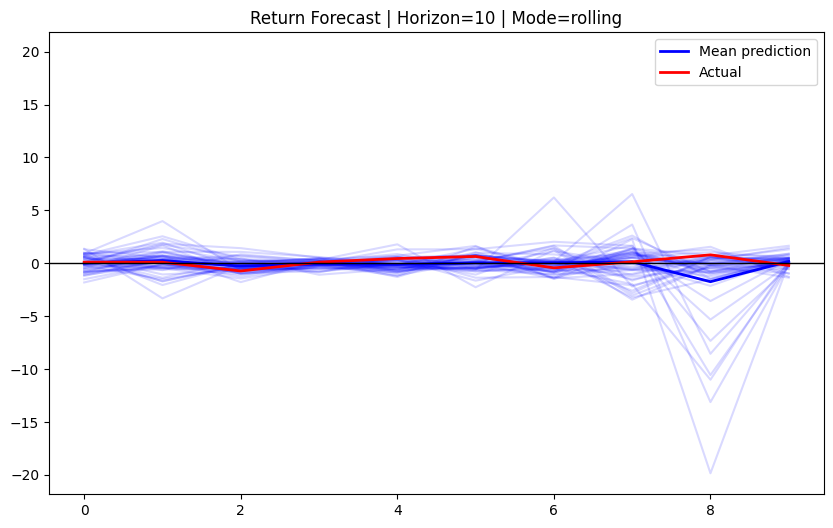

In [29]:
prices_series = np.exp(np.cumsum(returns_array))

forecast_visual(flow, X, returns_array, idx=-200)

## All the testing and results finance version

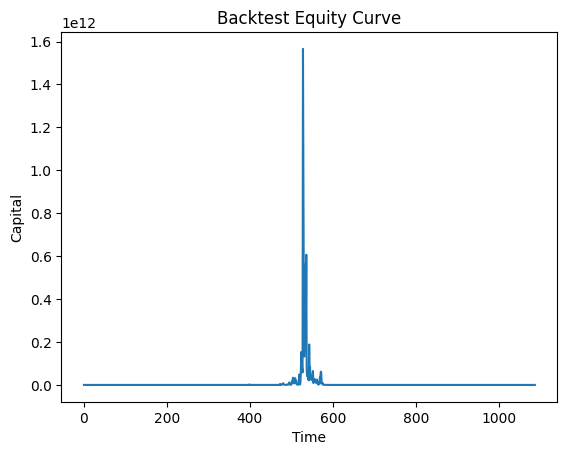


PERFORMANCE METRICS
Expected return: 0.011378497631061907
Volatility: 1.2971722750319465
Sharpe ratio: 0.00877177060447247
Max drawdown: 1.0
Value at Risk (95%): -1.8390761733055114
Expected Shortfall (95%): -2.9282381724142894
Baseline MSE: 1.1629891


In [30]:
## Backtesting

equity = simple_backtest(
    flow,
    X_test,
    Y_test
)

plt.figure()

plt.plot(equity)

plt.title("Backtest Equity Curve")

plt.xlabel("Time")

plt.ylabel("Capital")

plt.show()

## Core risk metrics

returns = compute_return_series(equity)

print("\nPERFORMANCE METRICS")

print("Expected return:", expected_return(returns))

print("Volatility:", volatility(returns))

print("Sharpe ratio:", sharpe_ratio(returns))

print("Max drawdown:", max_drawdown(equity))

## Value at risk

var_95 = value_at_risk(
    returns,
    alpha=0.05
)

print("Value at Risk (95%):", var_95)

## Expected shortfall

cvar_95 = expected_shortfall(
    returns,
    alpha=0.05
)

print("Expected Shortfall (95%):", cvar_95)

## Baseline model

mean, std = baseline_model(Y_train)

evaluate_baseline(
    mean,
    Y_test
)

## Distribution Test

In [31]:
def distribution_test(flow, X_test, Y_test):

    idx = np.random.randint(0, len(X_test))
    context = X_test[idx].unsqueeze(0)

    with torch.no_grad():
        gen = flow.sample(1000, context=context).cpu().numpy().flatten()

    real = Y_test.cpu().numpy().flatten()

    print("Real mean:", real.mean(), "Gen mean:", gen.mean())
    print("Real std:", real.std(), "Gen std:", gen.std())

## Histogram Match Test

In [32]:
def histogram_test(flow, X_test, Y_test):

    idx = np.random.randint(0, len(X_test))
    context = X_test[idx].unsqueeze(0)

    with torch.no_grad():
        gen = flow.sample(2000, context=context).cpu().numpy().flatten()

    real = Y_test.cpu().numpy().flatten()

    plt.figure()
    plt.hist(real, bins=50, alpha=0.5, density=True, label="Real")
    plt.hist(gen, bins=50, alpha=0.5, density=True, label="Generated")
    plt.legend()
    plt.title("Distribution Match")
    plt.show()

## Pit Test (Calibration)

In [33]:
def pit_test(flow, X_test, Y_test):

    pits = []

    for i in range(min(200, len(X_test))):

        context = X_test[i].unsqueeze(0)

        with torch.no_grad():
            samples = flow.sample(500, context=context).cpu().numpy().flatten()

        real = Y_test[i].item()

        pits.append(np.mean(samples < real))

    plt.hist(pits, bins=20)
    plt.title("PIT Test (should be uniform)")
    plt.show()

## Volatility Test

In [34]:
def volatility_test(flow, X_test):

    vols = []

    for i in range(100):

        context = X_test[i].unsqueeze(0)

        with torch.no_grad():
            samples = flow.sample(200).cpu().numpy().flatten()

        vols.append(np.std(samples))

    print("Mean generated volatility:", np.mean(vols))

## Auto correlation test

In [35]:
def autocorr(x, lag=1):
    return np.corrcoef(x[:-lag], x[lag:])[0,1]


def autocorr_test(flow, X_test):

    series = []

    for i in range(200):

        context = X_test[i].unsqueeze(0)

        with torch.no_grad():
            s = flow.sample(1, context=context).item()

        series.append(s)

    series = np.array(series)

    print("Autocorr:", autocorr(series))

## All the tests distribution version

Real mean: -0.014561396 Gen mean: 0.028344287
Real std: 1.0783563 Gen std: 1.1103306


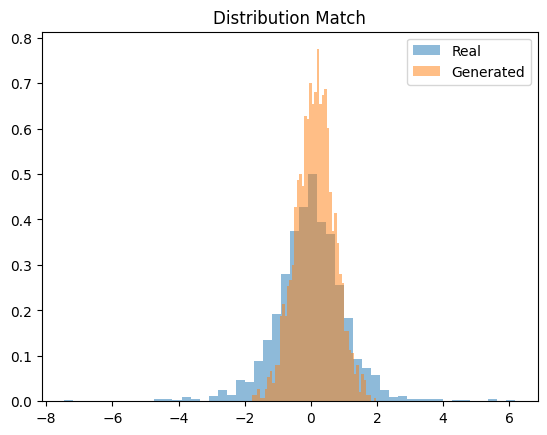

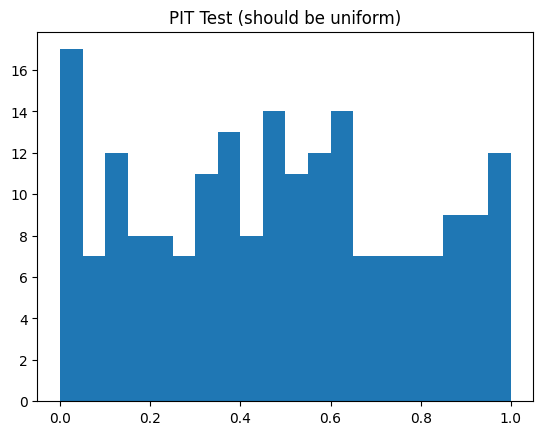

Mean generated volatility: 0.99892455
Autocorr: 0.013139701970984524


In [36]:
distribution_test(flow, X_test, Y_test)
histogram_test(flow, X_test, Y_test)
pit_test(flow, X_test, Y_test)
volatility_test(flow, X_test)
autocorr_test(flow, X_test)